In [2]:
# 1️⃣ Clonar con historial completo
!git clone https://github.com/caltamiranda/MCE-ROI-V2.git


fatal: destination path 'MCE-ROI-V2' already exists and is not an empty directory.


In [3]:
import inspect
import sys
sys.path.append("/kaggle/working/MCE-ROI-V2/rf_pipeline")
sys.path.append("/kaggle/working/MCE-ROI-V2")



In [ ]:
import os
import time
import numpy as np
import h5py
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from skimage.transform import resize
import sys

# Ajusta esto si tu carpeta rf_pipeline está en otro lado
sys.path.append("/kaggle/working/MCE-ROI-V2/MCE-ROI-V2") 
from core.preprocessing import Preprocessor
import config as cfg

# ==========================================
# 1. CONFIGURACIÓN OPTIMIZADA
# ==========================================
class CFG:
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    EPOCHS = 500
    PATIENCE = 30             # Un poco más de paciencia al ir más rápido
    
    # 🚀 OPTIMIZACIONES DE VELOCIDAD
    BATCH_SIZE = 64           # Subido de 16 a 64 (La T4 tiene 16GB VRAM, aguanta fácil)
    NUM_WORKERS = os.cpu_count() # Usa todos los núcleos disponibles (4 en Kaggle)
    
    LR = 1e-3
    IMG_SIZE = (256, 256)
    
    H5_TRAIN = "/kaggle/input/rf-benchmark/rf_benchmark/raw_iq_hdf5/train/data.h5" 
    H5_VAL = "/kaggle/input/rf-benchmark/rf_benchmark/raw_iq_hdf5/val/data.h5"
    OUTPUT_DIR = "/kaggle/working/"

# Aceleración de Hardware
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True # ⚡ Acelera convoluciones con tamaño fijo

# ==========================================
# 2. MODELO TINY U-NET
# ==========================================
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)

class TinyUNet(nn.Module):
    def __init__(self, n_channels=3, n_classes=1):
        super(TinyUNet, self).__init__()
        self.n_channels = n_channels
        self.n_classes = n_classes

        self.inc = DoubleConv(n_channels, 16)
        self.down1 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(16, 32))
        self.down2 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(32, 64))
        self.bot = DoubleConv(64, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.conv1 = DoubleConv(96, 64) 
        self.conv_up1 = DoubleConv(96, 64) 
        
        self.up2 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.conv_up2 = DoubleConv(48, 32)

        self.outc = nn.Conv2d(32, n_classes, kernel_size=1)

    def forward(self, x):
        x1 = self.inc(x)        
        x2 = self.down1(x1)     
        x3 = self.down2(x2)     
        x4 = self.bot(x3)       
        
        x = self.up1(x4)        
        diffY = x2.size()[2] - x.size()[2]
        diffX = x2.size()[3] - x.size()[3]
        x = F.pad(x, [diffX // 2, diffX - diffX // 2, diffY // 2, diffY - diffY // 2])
        x = torch.cat([x2, x], dim=1) 
        x = self.conv_up1(x)
        
        x = self.up2(x)
        diffY = x1.size()[2] - x.size()[2]
        diffX = x1.size()[3] - x.size()[3]
        x = F.pad(x, [diffX // 2, diffX - diffX // 2, diffY // 2, diffY - diffY // 2])
        x = torch.cat([x1, x], dim=1) 
        x = self.conv_up2(x)
        
        logits = self.outc(x)
        return torch.sigmoid(logits)

# ==========================================
# 3. TVERSKY LOSS
# ==========================================
class TverskyLoss(nn.Module):
    def __init__(self, alpha=0.3, beta=0.7, smooth=1.):
        super().__init__()
        self.alpha = alpha
        self.beta = beta
        self.smooth = smooth

    def forward(self, pred, target):
        pred = pred.view(-1)
        target = target.view(-1)
        TP = (pred * target).sum()
        FP = ((1 - target) * pred).sum()
        FN = (target * (1 - pred)).sum()
        tversky_index = (TP + self.smooth) / (TP + self.alpha * FP + self.beta * FN + self.smooth)
        return 1 - tversky_index

# ==========================================
# 4. DATASET
# ==========================================
class RPNDataset(Dataset):
    def __init__(self, h5_path, target_size=(256, 256)):
        self.h5_path = h5_path
        self.target_size = target_size
        self.keys = []
        try:
            with h5py.File(h5_path, 'r') as f:
                self.keys = [k for k in f.keys() if k.isdigit()]
        except Exception as e:
            print(f"Error abriendo {h5_path}: {e}")
            
        self.pre = Preprocessor(fs=cfg.FS, nperseg=cfg.NPERSEG, noverlap=cfg.NOVERLAP, mode="mce")

    def __len__(self):
        return len(self.keys)

    def _meta_to_box(self, meta_group, S_shape):
        C, H, W = S_shape
        try:
            start = meta_group['start_in_samples'][()]
            dur = meta_group['duration_in_samples'][()]
            if '_lower_frequency' in meta_group: flo = meta_group['_lower_frequency'][()]
            elif 'low_freq' in meta_group: flo = meta_group['low_freq'][()]
            else: return None
            if '_upper_frequency' in meta_group: fhi = meta_group['_upper_frequency'][()]
            elif 'high_freq' in meta_group: fhi = meta_group['high_freq'][()]
            else: return None
        except: return None

        hop = cfg.NPERSEG - cfg.NOVERLAP
        x1 = int(start / hop)
        x2 = int((start + dur) / hop)
        f_min, f_max = -cfg.FS/2, cfg.FS/2
        y1 = int(((flo - f_min)/(f_max - f_min)) * H)
        y2 = int(((fhi - f_min)/(f_max - f_min)) * H)
        return [max(0, x1), max(0, y1), min(W, x2), min(H, y2)]

    def __getitem__(self, idx):
        # H5py requiere abrir el archivo en cada worker si usamos multiprocesamiento
        with h5py.File(self.h5_path, 'r', libver='latest', swmr=True) as f: # Optimizacion de lectura
            key = self.keys[idx]
            ds = f[key]['data'][:]
            if ds.ndim > 1 and ds.shape[-1] == 2:
                iq = ds[..., 0] + 1j * ds[..., 1]
            else: iq = ds
            iq = np.squeeze(iq)

            S_mce = self.pre.compute(iq)
            S_mce = np.fft.fftshift(S_mce, axes=1)
            C, H, W = S_mce.shape

            mask = np.zeros((H, W), dtype=np.float32)
            if 'metadata' in f[key]:
                m_grp = f[key]['metadata']
                for k in m_grp.keys():
                    box = self._meta_to_box(m_grp[k], S_mce.shape)
                    if box:
                        x1, y1, x2, y2 = box
                        mask[y1:y2, x1:x2] = 1.0

        S_mce_t = np.transpose(S_mce, (1, 2, 0)) 
        S_resized = resize(S_mce_t, self.target_size, mode='reflect', anti_aliasing=True)
        S_final = np.transpose(S_resized, (2, 0, 1)).astype(np.float32)

        mask_resized = resize(mask, self.target_size, order=0, mode='reflect', anti_aliasing=False)
        mask_final = mask_resized.astype(np.float32)
        
        return torch.tensor(S_final), torch.tensor(mask_final).unsqueeze(0)

# ==========================================
# 5. ENTRENAMIENTO RÁPIDO
# ==========================================
print(f"=== Inicializando en {CFG.DEVICE} | Workers: {CFG.NUM_WORKERS} | Batch: {CFG.BATCH_SIZE} ===")
ds_train = RPNDataset(CFG.H5_TRAIN, target_size=CFG.IMG_SIZE)
ds_val = RPNDataset(CFG.H5_VAL, target_size=CFG.IMG_SIZE)

if len(ds_train) == 0:
    print("❌ Error: No se encontraron datos. Revisa las rutas.")
else:
    # ⚡ DATALOADER OPTIMIZADO
    dl_train = DataLoader(
        ds_train, 
        batch_size=CFG.BATCH_SIZE, 
        shuffle=True, 
        num_workers=CFG.NUM_WORKERS, # Usa 4 workers
        pin_memory=True,             # Acelera transferencia a GPU
        persistent_workers=True      # Mantiene vivos los procesos (evita overhead)
    )
    
    dl_val = DataLoader(
        ds_val, 
        batch_size=CFG.BATCH_SIZE, 
        shuffle=False, 
        num_workers=CFG.NUM_WORKERS,
        pin_memory=True,
        persistent_workers=True
    )

    model = TinyUNet(n_channels=3, n_classes=1).to(CFG.DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=CFG.LR)
    criterion = TverskyLoss(alpha=0.3, beta=0.7) 
    
    # LR Scheduler: Si se estanca, baja el Learning Rate
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=10, verbose=True)

    print(f"Train samples: {len(ds_train)} | Val samples: {len(ds_val)}")
    
    best_score = -1.0 
    epochs_no_improve = 0
    
    for epoch in range(CFG.EPOCHS):
        start = time.time()
        
        # --- TRAIN ---
        model.train()
        train_loss = 0
        
        for imgs, masks in dl_train:
            imgs, masks = imgs.to(CFG.DEVICE, non_blocking=True), masks.to(CFG.DEVICE, non_blocking=True)
            
            optimizer.zero_grad()
            preds = model(imgs) 
            loss = criterion(preds, masks)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        # --- VAL ---
        model.eval()
        val_score_accum = 0 
        
        with torch.no_grad():
            for imgs, masks in dl_val:
                imgs, masks = imgs.to(CFG.DEVICE, non_blocking=True), masks.to(CFG.DEVICE, non_blocking=True)
                preds = model(imgs)
                loss = criterion(preds, masks)
                val_score_accum += (1 - loss.item())

        avg_train_loss = train_loss / len(dl_train)
        avg_val_score = val_score_accum / len(dl_val)
        epoch_time = time.time() - start
        
        # Scheduler step
        scheduler.step(avg_val_score)
        
        print(f"Epoch {epoch+1}/{CFG.EPOCHS} [{epoch_time:.1f}s] | "
              f"Train Loss: {avg_train_loss:.4f} | "
              f"Val Tversky Score: {avg_val_score:.2%}")
        
        if avg_val_score > best_score:
            best_score = avg_val_score
            epochs_no_improve = 0
            torch.save(model.state_dict(), os.path.join(CFG.OUTPUT_DIR, "best_unet_rpn.pt"))
        else:
            epochs_no_improve += 1
            
        if epochs_no_improve >= CFG.PATIENCE:
            print(f"\n⏹️ Early Stopping activado en la época {epoch+1}.")
            break

    print(f"\n✅ Entrenamiento finalizado. Mejor Score: {best_score:.2%}")

=== Inicializando en cuda | Workers: 4 | Batch: 64 ===
Train samples: 21000 | Val samples: 4500


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1/500 [744.9s] | Train Loss: 0.3532 | Val Tversky Score: 85.98%
Epoch 2/500 [618.6s] | Train Loss: 0.1060 | Val Tversky Score: 90.17%
Epoch 3/500 [637.7s] | Train Loss: 0.0826 | Val Tversky Score: 82.48%


In [68]:
import torch
import numpy as np
from skimage.transform import resize
from scipy.ndimage import label, find_objects
from dataclasses import dataclass

# Asegúrate de que la clase ROI esté definida
@dataclass
class ROI:
    y1: int; x1: int; y2: int; x2: int
    score: float
    snr_db: float = 0.0

class NeuralROIDetector:
    def __init__(self, model_path, model_class, device='cuda', input_size=(256, 256), threshold=0.5):
        self.device = device
        self.input_size = input_size
        self.threshold = threshold
        
        print(f"[NeuralROI] Cargando RPN desde {model_path}...")
        self.model = model_class(n_channels=3, n_classes=1).to(device)
        self.model.load_state_dict(torch.load(model_path, map_location=device))
        self.model.eval()

    def detect(self, S_mce: np.ndarray) -> list:
        """
        S_mce: Input [3, H, W] (Tamaño original)
        Retorna: Lista de objetos ROI en coordenadas originales
        """
        orig_c, orig_h, orig_w = S_mce.shape
        
        # 1. Preprocesamiento (Resize a 256x256 para la U-Net)
        # Transponer a [H, W, C] para skimage
        img_t = np.transpose(S_mce, (1, 2, 0)) 
        img_resized = resize(img_t, self.input_size, mode='reflect', anti_aliasing=True)
        # Volver a [C, H, W] y convertir a Tensor
        img_final = np.transpose(img_resized, (2, 0, 1)).astype(np.float32)
        tensor_in = torch.from_numpy(img_final).unsqueeze(0).to(self.device) # [1, 3, 256, 256]

        # 2. Inferencia Neuronal
        with torch.no_grad():
            # Salida: [1, 1, 256, 256] -> Probabilidad de energía
            prob_map = self.model(tensor_in).squeeze().cpu().numpy()
            
        # 3. Binarización (Máscara)
        mask = prob_map > self.threshold
        
        # 4. Extracción de Cajas
        labeled, num_features = label(mask)
        slices = find_objects(labeled)
        
        rois = []
        
        # Factores de escala para volver al tamaño original
        scale_y = orig_h / self.input_size[0]
        scale_x = orig_w / self.input_size[1]

        for slc in slices:
            if slc is None: continue
            y1_net, y2_net = slc[0].start, slc[0].stop
            x1_net, x2_net = slc[1].start, slc[1].stop
            
            # 5. Re-escalado de coordenadas (De 256 -> Original)
            y1 = int(y1_net * scale_y)
            y2 = int(y2_net * scale_y)
            x1 = int(x1_net * scale_x)
            x2 = int(x2_net * scale_x)
            
            # Score promedio dentro de la máscara detectada
            score = float(np.mean(prob_map[y1_net:y2_net, x1_net:x2_net]))
            
            # Filtro mínimo (en píxeles originales)
            if (y2-y1) > 2 and (x2-x1) > 4:
                rois.append(ROI(y1, x1, y2, x2, score))

        # Ordenar por confianza
        return sorted(rois, key=lambda r: r.score, reverse=True)

In [54]:
import sys
sys.path.append("/kaggle/working/MCE-ROI-V2/MCE-ROI-V2/rf_pipeline")
sys.path.append("/kaggle/working/MCE-ROI-V2/MCE-ROI-V2")
import numpy as np
from scipy.ndimage import label, find_objects, generate_binary_structure, binary_dilation
from skimage.morphology import disk, white_tophat
from dataclasses import dataclass
from typing import List, Tuple

@dataclass
class ROI:
    y1: int; x1: int; y2: int; x2: int
    score: float
    snr_db: float = 0.0

class AdaptiveROIDetector:
    def __init__(
        self,
        high_sigma: float = 3.0,     
        low_sigma: float = 2.0,      
        min_area: int = 50,          
        min_width: int = 4,
        min_height: int = 2,
        # Tolerancias a CERO para respetar desvanecimientos
        time_tol: int = 0,           
        freq_tol: int = 0,
        # Nuevo parámetro: Umbral de solapamiento (10%)
        overlap_thresh: float = 0.10 
    ):
        self.high_sigma = high_sigma
        self.low_sigma = low_sigma
        self.min_area = min_area
        self.min_width = min_width
        self.min_height = min_height
        self.time_tol = time_tol
        self.freq_tol = freq_tol
        self.overlap_thresh = overlap_thresh

    def _robust_noise_floor(self, img: np.ndarray) -> Tuple[float, float]:
        arr = img.ravel()
        p25, p50 = np.percentile(arr, [25, 50])
        noise_floor = p50
        noise_sigma = (p50 - p25) / 0.6745
        return noise_floor, max(noise_sigma, 1e-9)

    def _should_merge(self, boxA, boxB):
        """
        Determina si dos cajas deben unirse basándose ESTRICTAMENTE en solapamiento > 10%.
        """
        ay1, ax1, ay2, ax2, _ = boxA
        by1, bx1, by2, bx2, _ = boxB

        # 1. Calcular coordenadas de la intersección
        iy1 = max(ay1, by1)
        ix1 = max(ax1, bx1)
        iy2 = min(ay2, by2)
        ix2 = min(ax2, bx2)

        # 2. Verificar si hay intersección física
        if iy2 > iy1 and ix2 > ix1:
            inter_area = (iy2 - iy1) * (ix2 - ix1)
            area_a = (ay2 - ay1) * (ax2 - ax1)
            area_b = (by2 - by1) * (bx2 - bx1)

            # 3. Criterio del 10%:
            # Usamos min(area_a, area_b) para que si una caja pequeña está dentro
            # de una grande, se detecte el solapamiento significativo relativo a la pequeña.
            overlap_ratio = inter_area / min(area_a, area_b)
            
            return overlap_ratio > self.overlap_thresh
        
        return False

    def _merge_boxes(self, boxes):
        if not boxes: return []
        merged = boxes.copy()
        changed = True
        
        while changed:
            changed = False
            new_merged = []
            while merged:
                a = merged.pop(0)
                was_merged = False
                
                # Iterar sobre el resto para buscar fusiones
                for i, b in enumerate(merged):
                    if self._should_merge(a, b):
                        # Fusionar coordenadas (Bounding Box envolvente)
                        ay1, ax1, ay2, ax2, ascore = a
                        by1, bx1, by2, bx2, bscore = b
                        
                        ny1 = min(ay1, by1); nx1 = min(ax1, bx1)
                        ny2 = max(ay2, by2); nx2 = max(ax2, bx2)
                        nscore = max(ascore, bscore) # Conservar el mejor score
                        
                        merged[i] = [ny1, nx1, ny2, nx2, nscore]
                        was_merged = True
                        changed = True
                        break # Romper para reiniciar el ciclo con la nueva caja
                
                if not was_merged:
                    new_merged.append(a)
            merged = new_merged
        return merged

    def detect(self, S_det: np.ndarray) -> List[ROI]:
        mu, sigma = self._robust_noise_floor(S_det)
        z_img = (S_det - mu) / sigma

        # Detección
        tophat = white_tophat(z_img, footprint=disk(3))
        weak = (z_img > self.low_sigma) | (tophat > self.low_sigma * 1.5)
        strong = z_img > self.high_sigma

        # Máscara inicial
        mask = binary_dilation(strong, mask=weak, structure=generate_binary_structure(2, 2))
        
        # ⚠️ NOTA IMPORANTE:
        # Eliminé 'closing' y morfología direccional.
        # Esto respeta tu deseo de "dejar perder el desvanecimiento".
        # Si la señal se corta en el espectrograma, se cortará en la caja.
        
        labeled, _ = label(mask)
        slices = find_objects(labeled)
        
        raw_boxes = []
        for slc in slices:
            if slc is None: continue
            y1, y2 = slc[0].start, slc[0].stop
            x1, x2 = slc[1].start, slc[1].stop
            
            if (x2 - x1) < self.min_width or (y2 - y1) < self.min_height:
                continue

            roi_z = z_img[y1:y2, x1:x2]
            score = float(np.percentile(roi_z, 90))
            raw_boxes.append([y1, x1, y2, x2, score])

        # Fusión estricta (Solo overlap > 10%)
        merged = self._merge_boxes(raw_boxes)
        
        final_rois = []
        for b in merged:
            if (b[2]-b[0])*(b[3]-b[1]) >= self.min_area:
                final_rois.append(ROI(b[0], b[1], b[2], b[3], b[4]))

        return sorted(final_rois, key=lambda r: r.score, reverse=True)

# 🚀 Inyectar la clase
import core.roi_detection
core.roi_detection.AdaptiveROIDetector = AdaptiveROIDetector
core.roi_detection.ROI = ROI
print("✅ AdaptiveROIDetector: Modo Estricto (Overlap > 10%) activado.")


✅ AdaptiveROIDetector: Modo Estricto (Overlap > 10%) activado.


In [5]:
from rf_pipeline.models.hybrid_classifier import HybridRFClassifier


In [6]:
import os
import sys
import importlib

# 1. Definimos el contenido que necesita el repositorio
config_content = """
import os

# --- Parámetros de Señal ---
FS = 10_000_000      
CENTER_FREQ = 0      

# --- Parámetros STFT / Preprocesamiento ---
NPERSEG = 32
NOVERLAP = 16
NFFT = 32            
IMG_SIZE = 256        

# --- Entrenamiento ---
BATCH_SIZE = 128
EPOCHS = 50
LR = 1e-3
DEVICE = "cuda"

# --- Rutas Dummy (se sobrescriben en el notebook, pero deben existir aquí) ---
TRAIN_H5 = ""
VAL_H5 = ""
"""

# 2. Escribimos el archivo config.py en la ruta donde el repo lo busca
repo_path = "/kaggle/working/MCE-ROI-V2"
config_path = os.path.join(repo_path, "config.py")

with open(config_path, "w") as f:
    f.write(config_content)
print(f"Archivo de configuración creado en: {config_path}")

# 3. Forzamos la recarga del módulo config para que Python vea los cambios
# (Esto es necesario si ya intentaste correr la celda anterior y falló)
try:
    import config
    importlib.reload(config)
    print("Módulo config recargado exitosamente.")
except ImportError:
    print("El módulo config se cargará automáticamente en el siguiente paso.")

# 4. Ahora sí importamos las librerías del repo correctamente
import rf_pipeline.core.data_loader
importlib.reload(rf_pipeline.core.data_loader)
from rf_pipeline.core.data_loader import H5HybridDetectionDataset

print("✅ H5HybridDetectionDataset importado correctamente.")


Archivo de configuración creado en: /kaggle/working/MCE-ROI-V2/config.py
Módulo config recargado exitosamente.
✅ H5HybridDetectionDataset importado correctamente.


In [7]:
import torch

class CFG:
    # --- Rutas Exactas ---
    # Asumo que dentro de las carpetas hay un archivo llamado 'data.h5'
    # Si el archivo tiene otro nombre (ej: 'train.h5'), cámbialo al final de la ruta.
    TRAIN_H5 = "/kaggle/input/rf-benchmark-tiny/raw_iq_hdf5/train/data.h5"
    VAL_H5   = "/kaggle/input/rf-benchmark-tiny/raw_iq_hdf5/val/data.h5" # (Ajusta si la ruta de val es distinta)
    TEST_H5  = "/kaggle/input/rf-benchmark-tiny/raw_iq_hdf5/test/data.h5"

    OUTPUT_DIR = "/kaggle/working/resultados_finales"
    
    # Parámetros (Deben coincidir con los del config.py creado arriba)
    BATCH_SIZE = 128
    EPOCHS = 10
    LR = 1e-3
    NUM_WORKERS = 2
    
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

os.makedirs(CFG.OUTPUT_DIR, exist_ok=True)
print(f"Entrenando en: {CFG.DEVICE}")

Entrenando en: cuda


In [8]:
from torch.utils.data import DataLoader
import core.data_loader
importlib.reload(core.data_loader) # Recarga segura
from core.data_loader import H5HybridDetectionDataset

print("--- Cargando Datasets ---")

# 1. TRAIN (Para entrenar pesos)
ds_train = H5HybridDetectionDataset(CFG.TRAIN_H5, mode="train")

# 2. VAL (Para validar loss/accuracy en cada época y guardar el mejor modelo)
# Usamos mode="train" para que nos devuelva tensores listos para clasificar, no imágenes completas.
ds_val = H5HybridDetectionDataset(CFG.VAL_H5, mode="train")

# 3. TEST (Para evaluación final)
ds_test = H5HybridDetectionDataset(CFG.TEST_H5, mode="train")

# DataLoaders
dl_train = DataLoader(ds_train, batch_size=CFG.BATCH_SIZE, shuffle=True, num_workers=CFG.NUM_WORKERS, pin_memory=True)
dl_val   = DataLoader(ds_val, batch_size=CFG.BATCH_SIZE*2, shuffle=False, num_workers=CFG.NUM_WORKERS, pin_memory=True)
dl_test  = DataLoader(ds_test, batch_size=CFG.BATCH_SIZE*2, shuffle=False, num_workers=CFG.NUM_WORKERS, pin_memory=True)

print(f"Muestras de Train: {len(ds_train)}")
print(f"Muestras de Val:   {len(ds_val)}")
print(f"Muestras de Test:  {len(ds_test)}")

--- Cargando Datasets ---
Muestras de Train: 700
Muestras de Val:   150
Muestras de Test:  150


In [9]:
from models.hybrid_classifier import HybridRFClassifier
import torch.optim as optim
import torch.nn as nn

model = HybridRFClassifier(
    num_classes=2, 
    feat_dim=32,
    img_in_ch=3,
    cnn_channels=(16, 32, 64),
    mlp_hidden=(64, 64)
).to(CFG.DEVICE)

optimizer = optim.Adam(model.parameters(), lr=CFG.LR)
criterion = nn.CrossEntropyLoss()

In [10]:
batch = next(iter(dl_train))
print(type(batch))
print(len(batch))
print([type(x) for x in batch])


/kaggle/working/MCE-ROI-V2/rf_pipeline/core/preprocessing.py:24: UserWarning: Input data is complex, switching to return_onesided=False
  f, t, Zxx = stft(iq_signal, fs=self.fs, nperseg=self.nperseg, noverlap=self.noverlap)
/kaggle/working/MCE-ROI-V2/rf_pipeline/core/preprocessing.py:24: UserWarning: Input data is complex, switching to return_onesided=False
  f, t, Zxx = stft(iq_signal, fs=self.fs, nperseg=self.nperseg, noverlap=self.noverlap)


<class 'list'>
3
[<class 'torch.Tensor'>, <class 'torch.Tensor'>, <class 'torch.Tensor'>]


In [11]:
import time
import numpy as np
from sklearn.metrics import accuracy_score

best_val_acc = 0.0
history = []

print("=== Inicio del Entrenamiento ===")

for epoch in range(CFG.EPOCHS):
    start = time.time()
    
    # --- TRAIN ---
    model.train()
    train_loss = 0
    preds_t, targets_t = [], []
    
    for x_vis, x_eng, y in dl_train:
        x_vis, x_eng, y = x_vis.to(CFG.DEVICE), x_eng.to(CFG.DEVICE), y.to(CFG.DEVICE)
        
        optimizer.zero_grad()
        logits = model(x_vis, x_eng)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        preds_t.extend(torch.argmax(logits, dim=1).cpu().numpy())
        targets_t.extend(y.cpu().numpy())

    # --- VAL ---
    model.eval()
    val_loss = 0
    preds_v, targets_v = [], []
    
    with torch.no_grad():
        for x_vis, x_eng, y in dl_val:
            x_vis, x_eng, y = x_vis.to(CFG.DEVICE), x_eng.to(CFG.DEVICE), y.to(CFG.DEVICE)
            logits = model(x_vis, x_eng)
            val_loss += criterion(logits, y).item()
            preds_v.extend(torch.argmax(logits, dim=1).cpu().numpy())
            targets_v.extend(y.cpu().numpy())

    # Métricas
    t_acc = accuracy_score(targets_t, preds_t)
    v_acc = accuracy_score(targets_v, preds_v)
    epoch_time = time.time() - start
    
    print(f"Epoch {epoch+1}/{CFG.EPOCHS} [{epoch_time:.1f}s] | "
          f"Train Acc: {t_acc:.2%} Loss: {train_loss/len(dl_train):.4f} | "
          f"Val Acc: {v_acc:.2%} Loss: {val_loss/len(dl_val):.4f}")
    
    # Guardar el mejor
    if v_acc > best_val_acc:
        best_val_acc = v_acc
        torch.save(model.state_dict(), os.path.join(CFG.OUTPUT_DIR, "best_model.pt"))

print(f"\nEntrenamiento finalizado. Mejor Val Acc: {best_val_acc:.2%}")

=== Inicio del Entrenamiento ===


/kaggle/working/MCE-ROI-V2/rf_pipeline/core/preprocessing.py:24: UserWarning: Input data is complex, switching to return_onesided=False
  f, t, Zxx = stft(iq_signal, fs=self.fs, nperseg=self.nperseg, noverlap=self.noverlap)
/kaggle/working/MCE-ROI-V2/rf_pipeline/core/preprocessing.py:24: UserWarning: Input data is complex, switching to return_onesided=False
  f, t, Zxx = stft(iq_signal, fs=self.fs, nperseg=self.nperseg, noverlap=self.noverlap)
/kaggle/working/MCE-ROI-V2/rf_pipeline/core/preprocessing.py:24: UserWarning: Input data is complex, switching to return_onesided=False
  f, t, Zxx = stft(iq_signal, fs=self.fs, nperseg=self.nperseg, noverlap=self.noverlap)


Epoch 1/10 [14.9s] | Train Acc: 75.71% Loss: 0.4582 | Val Acc: 94.67% Loss: 0.5441


/kaggle/working/MCE-ROI-V2/rf_pipeline/core/preprocessing.py:24: UserWarning: Input data is complex, switching to return_onesided=False
  f, t, Zxx = stft(iq_signal, fs=self.fs, nperseg=self.nperseg, noverlap=self.noverlap)
/kaggle/working/MCE-ROI-V2/rf_pipeline/core/preprocessing.py:24: UserWarning: Input data is complex, switching to return_onesided=False
  f, t, Zxx = stft(iq_signal, fs=self.fs, nperseg=self.nperseg, noverlap=self.noverlap)
/kaggle/working/MCE-ROI-V2/rf_pipeline/core/preprocessing.py:24: UserWarning: Input data is complex, switching to return_onesided=False
  f, t, Zxx = stft(iq_signal, fs=self.fs, nperseg=self.nperseg, noverlap=self.noverlap)


Epoch 2/10 [14.7s] | Train Acc: 93.71% Loss: 0.2178 | Val Acc: 91.33% Loss: 0.2979


...

Epoch 8/10 [14.3s] | Train Acc: 96.29% Loss: 0.1101 | Val Acc: 97.33% Loss: 0.0801


/kaggle/working/MCE-ROI-V2/rf_pipeline/core/preprocessing.py:24: UserWarning: Input data is complex, switching to return_onesided=False
  f, t, Zxx = stft(iq_signal, fs=self.fs, nperseg=self.nperseg, noverlap=self.noverlap)
/kaggle/working/MCE-ROI-V2/rf_pipeline/core/preprocessing.py:24: UserWarning: Input data is complex, switching to return_onesided=False
  f, t, Zxx = stft(iq_signal, fs=self.fs, nperseg=self.nperseg, noverlap=self.noverlap)
/kaggle/working/MCE-ROI-V2/rf_pipeline/core/preprocessing.py:24: UserWarning: Input data is complex, switching to return_onesided=False
  f, t, Zxx = stft(iq_signal, fs=self.fs, nperseg=self.nperseg, noverlap=self.noverlap)


Epoch 9/10 [14.5s] | Train Acc: 95.14% Loss: 0.1388 | Val Acc: 96.00% Loss: 0.1220


/kaggle/working/MCE-ROI-V2/rf_pipeline/core/preprocessing.py:24: UserWarning: Input data is complex, switching to return_onesided=False
  f, t, Zxx = stft(iq_signal, fs=self.fs, nperseg=self.nperseg, noverlap=self.noverlap)
/kaggle/working/MCE-ROI-V2/rf_pipeline/core/preprocessing.py:24: UserWarning: Input data is complex, switching to return_onesided=False
  f, t, Zxx = stft(iq_signal, fs=self.fs, nperseg=self.nperseg, noverlap=self.noverlap)
/kaggle/working/MCE-ROI-V2/rf_pipeline/core/preprocessing.py:24: UserWarning: Input data is complex, switching to return_onesided=False
  f, t, Zxx = stft(iq_signal, fs=self.fs, nperseg=self.nperseg, noverlap=self.noverlap)


Epoch 10/10 [15.1s] | Train Acc: 96.00% Loss: 0.1062 | Val Acc: 97.33% Loss: 0.0810

Entrenamiento finalizado. Mejor Val Acc: 97.33%


In [71]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import time
import sys
import os
from tqdm import tqdm
from core.roi_detection import AdaptiveROIDetector   # ✔ Detector adaptativo correcto
from models.hybrid_classifier import HybridRFClassifier
from core.feature_engineering import FeatureEngineer
from core.visual_stream import VisualStream
from core.data_loader import H5HybridDetectionDataset
import config as cfg

class RFAnalysisPipeline:
    def __init__(self, classifier_path, rpn_path, device="cuda"):
        self.device = device if torch.cuda.is_available() else "cpu"
        print(f"[Pipeline] Inicializando en {self.device}...")

        # 1️⃣ Cargar CLASIFICADOR (Híbrido CNN+MLP)
        self.classifier = HybridRFClassifier(
            num_classes=2, feat_dim=32, img_in_ch=3,
            cnn_channels=(16, 32, 64), mlp_hidden=(64, 64)
        ).to(self.device)
        
        if os.path.exists(classifier_path):
            self.classifier.load_state_dict(torch.load(classifier_path, map_location=self.device))
            self.classifier.eval()
        else:
            print(f"⚠️ Advertencia: No se encontró el clasificador en {classifier_path}")

        # 2️⃣ Cargar DETECTOR NEURONAL (RPN U-Net) - ¡NUEVO!
        if os.path.exists(rpn_path):
            self.detector = NeuralROIDetector(
                model_path=rpn_path,
                model_class=TinyUNet, # Pasamos la clase definida en tu notebook
                device=self.device,
                threshold=0.5 # Ajustable: más bajo = más recall
            )
            print("✅ Neural RPN activado.")
        else:
            raise FileNotFoundError(f"Falta el modelo RPN: {rpn_path}")

        # Herramientas auxiliares
        self.fe = FeatureEngineer(fs=cfg.FS, nperseg=cfg.NPERSEG, noverlap=cfg.NOVERLAP)
        self.vs = VisualStream(target_size=cfg.IMG_SIZE)

    def predict(self, h5_path, confidence_thresh=0.5, max_samples=None):
        # ... (El resto de tu función predict permanece IGUAL) ...
        # Solo asegúrate de llamar a self.detector.detect(S_mce) 
        # NOTA: NeuralROIDetector usa S_mce (3 canales), NO S_det (1 canal)
        
        print(f"[Pipeline] Procesando: {h5_path}")
        ds = H5HybridDetectionDataset(h5_path, mode="eval")
        
        results = []
        indices = range(len(ds))
        if max_samples: indices = indices[:max_samples]

        for idx in tqdm(indices, desc="Inferencia Neuronal"):
            sample = ds[idx]
            S_mce = sample['S_mce'] # Usamos MCE completo para la U-Net
            iq = sample['iq']
            S_det = sample['S_det'] # Aún necesario para Feature Engineering
            gt_boxes = sample['gt_boxes']
            
            # --- DETECCIÓN (Ahora usa IA) ---
            # Pasamos S_mce [3, H, W]
            rois = self.detector.detect(S_mce) 
            
            predictions = []
            
            if len(rois) > 0:
                # Extraer features y clasificar (Igual que antes)
                roi_feats = self.fe.features_for_rois(iq, S_det, rois)
                feat_map = {(f.roi.y1, f.roi.x1, f.roi.y2, f.roi.x2): f.features for f in roi_feats}
                
                # Contexto visual para el clasificador
                patches = self.vs.extract_patches(S_mce, rois)
                
                X_vis, X_eng, valid_rois = [], [], []
                for k, r in enumerate(rois):
                    key = (r.y1, r.x1, r.y2, r.x2)
                    if key in feat_map and k < len(patches) and patches[k] is not None:
                        X_eng.append(torch.tensor(feat_map[key], dtype=torch.float32))
                        X_vis.append(torch.tensor(patches[k], dtype=torch.float32))
                        valid_rois.append(r)
                
                if len(X_vis) > 0:
                    X_vis = torch.stack(X_vis).to(self.device)
                    X_eng = torch.stack(X_eng).to(self.device)
                    
                    with torch.no_grad():
                        logits = self.classifier(X_vis, X_eng)
                        probs = F.softmax(logits, dim=1)[:, 1].cpu().numpy()
                        
                    for i, p in enumerate(probs):
                        if p >= confidence_thresh:
                            box = [valid_rois[i].x1, valid_rois[i].y1, valid_rois[i].x2, valid_rois[i].y2]
                            predictions.append({"box": box, "score": float(p)})
            
            # Guardar resultados...
            results.append({
                "id": idx, "S_mce": S_mce, "predictions": predictions, 
                "gt_boxes": gt_boxes, "inference_time_ms": 0 # (Calcula tu tiempo real)
            })
            
        return results

    def _calculate_iou(self, boxA, boxB):
        xA = max(boxA[0], boxB[0]); yA = max(boxA[1], boxB[1])
        xB = min(boxA[2], boxB[2]); yB = min(boxA[3], boxB[3])
        interArea = max(0, xB - xA) * max(0, yB - yA)
        boxAArea = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
        boxBArea = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])
        return interArea / float(boxAArea + boxBArea - interArea + 1e-6)

    def evaluate(self, results, iou_thresh=0.2):
        tp, fp, fn = 0, 0, 0
        total_time_ms = 0.0

        for res in results:
            total_time_ms += res['inference_time_ms']
            preds = res['predictions']
            gts = res['gt_boxes']

            matched_gt = [False] * len(gts)
            for p in preds:
                best_iou, best_gt_idx = 0, -1
                for i, gt in enumerate(gts):
                    iou = self._calculate_iou(p['box'], gt)
                    if iou > best_iou:
                        best_iou, best_gt_idx = iou, i

                if best_iou >= iou_thresh and not matched_gt[best_gt_idx]:
                    tp += 1
                    matched_gt[best_gt_idx] = True
                else:
                    fp += 1

            fn += matched_gt.count(False)

        precision = tp / (tp + fp + 1e-6)
        recall = tp / (tp + fn + 1e-6)
        f1 = 2 * (precision * recall) / (precision + recall + 1e-6)

        avg_time = total_time_ms / len(results) if results else 0
        fps = 1000.0 / avg_time if avg_time > 0 else 0

        print("\n" + "="*40)
        print(" REPORTE DE DESEMPEÑO (Sin tiempo STFT)")
        print("="*40)
        print(f"  - F1-Score:  {f1:.4f}")
        print(f"  - Precision: {precision:.4f}")
        print(f"  - Recall:    {recall:.4f}")
        print(f"  - Tiempo Promedio: {avg_time:.2f} ms")
        print(f"  - Velocidad:       {fps:.1f} FPS")
        print("="*40)

        return {"f1": f1, "prec": precision, "rec": recall, "ms": avg_time, "fps": fps}

    def evaluate_by_noise(self, results, iou_thresh=0.2):
        noise_groups = {}
        for res in results:
            if res.get("noise_level") is None:
                continue
            noise = int(res["noise_level"])
            noise_groups.setdefault(noise, []).append(res)

        print("\n" + "="*60)
        print("   REPORTE DE DESEMPEÑO POR NIVEL DE RUIDO (SNR)")
        print("="*60)

        metrics_by_noise = {}
        for noise, group in sorted(noise_groups.items()):
            print(f"\n🔹 Resultados para SNR = {noise} dB")
            metrics = self.evaluate(group, iou_thresh=iou_thresh)
            metrics_by_noise[noise] = metrics

        print("\n" + "="*60)
        print("   FIN DEL REPORTE POR RUIDO")
        print("="*60)
        return metrics_by_noise

    def visualize(self, results, num_samples=5):
        interesting = [r for r in results if len(r['predictions']) > 0 or len(r['gt_boxes']) > 0]
        to_show = interesting[:num_samples]

        if not to_show:
            print("No hay detecciones visualmente interesantes.")
            return

        for item in to_show:
            fig, ax = plt.subplots(figsize=(10, 3))
            ax.imshow(item['S_mce'][0], aspect='auto', origin='lower', cmap='viridis')

            for box in item['gt_boxes']:
                w, h = box[2] - box[0], box[3] - box[1]
                rect = mpatches.Rectangle((box[0], box[1]), w, h, linewidth=1,
                                          edgecolor='lime', facecolor='none')
                ax.add_patch(rect)

            for p in item['predictions']:
                box, score = p['box'], p['score']
                w, h = box[2] - box[0], box[3] - box[1]
                rect = mpatches.Rectangle((box[0], box[1]), w, h, linewidth=2,
                                          edgecolor='red', facecolor='none')
                ax.add_patch(rect)
                ax.text(box[0], box[1], f"{score:.0%}", color='white', fontsize=7,
                        backgroundcolor='red')

            t_ms = item['inference_time_ms']
            plt.title(f"ID {item['id']} | Tiempo Inferencia: {t_ms:.1f} ms")
            plt.tight_layout()
            plt.show()

print("Pipeline actualizado con Adaptive ROI y análisis por ruido (SNR).")


Pipeline actualizado con Adaptive ROI y análisis por ruido (SNR).


[Pipeline] Inicializando en cuda...
[NeuralROI] Cargando RPN desde /kaggle/working/best_unet_rpn.pt...
✅ Neural RPN activado.
[Pipeline] Procesando: /kaggle/input/rf-benchmark-tiny/raw_iq_hdf5/test/data.h5


Inferencia Neuronal: 100%|██████████| 150/150 [00:07<00:00, 20.94it/s]



 REPORTE DE DESEMPEÑO (Sin tiempo STFT)
  - F1-Score:  0.8272
  - Precision: 1.0000
  - Recall:    0.7053
  - Tiempo Promedio: 0.00 ms
  - Velocidad:       0.0 FPS


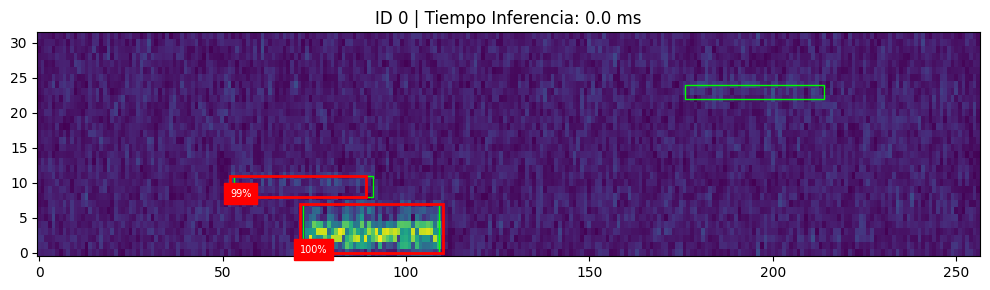

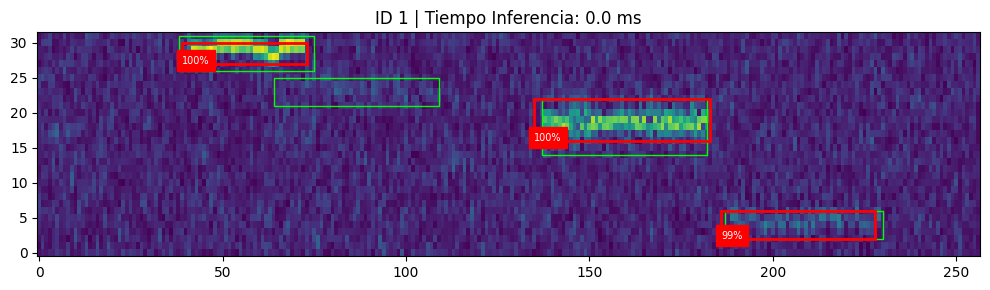

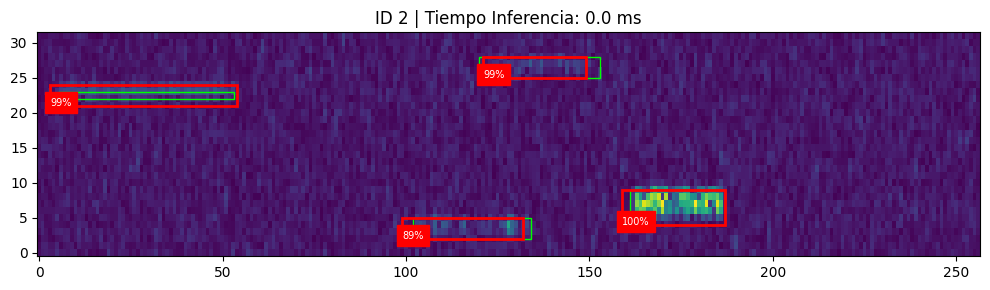

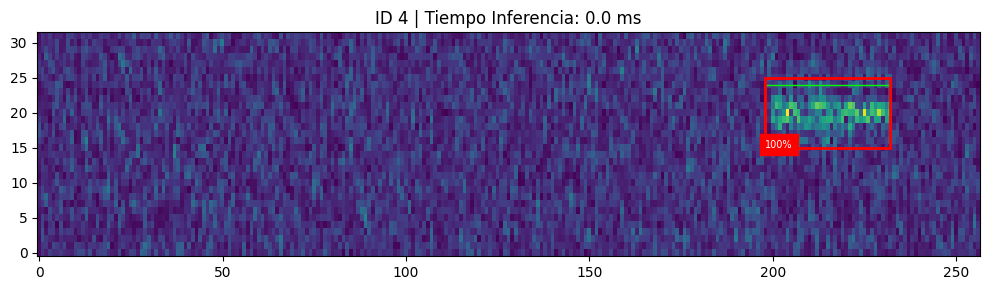

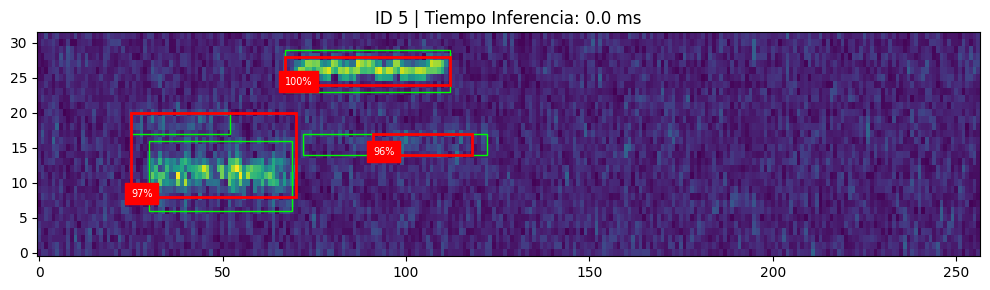

In [73]:
# Rutas a tus modelos entrenados
RPN_PATH = "/kaggle/working/best_unet_rpn.pt"         # El que acabas de entrenar
CLF_PATH = "/kaggle/working/resultados_finales/best_model.pt" # Tu clasificador anterior
TEST_DATA = "/kaggle/input/rf-benchmark-tiny/raw_iq_hdf5/test/data.h5"

# Instanciar Pipeline
pipeline = RFAnalysisPipeline(classifier_path=CLF_PATH, rpn_path=RPN_PATH)

# Ejecutar
results = pipeline.predict(TEST_DATA, confidence_thresh=0.2, max_samples=150)

# Evaluar
pipeline.evaluate(results)
pipeline.visualize(results)

In [ ]:
print(resultados[0].keys())
print(resultados[0].get("noise_level", "No encontrado"))


In [ ]:
!pip install thop


In [ ]:
from thop import profile
import torch

# Dummy input para imagen (ajusta tamaño según tu modelo)
x_img = torch.randn(1, 3, 224, 224).to(pipeline.device)

# Dummy input para features engineered (feat_dim = 32)
x_feat = torch.randn(1, 32).to(pipeline.device)

flops, params = profile(pipeline.model, inputs=(x_img, x_feat))

print(f"Total Parameters: {params:,}")
print(f"FLOPs: {flops:,}")
print(f"GFLOPs: {flops/1e9:.2f}")
